In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Configuration

In [15]:
DATA_PATH = "../emissions-data"

TARGET_COL = "Carbon intensity gCO\u2082eq/kWh (direct)"

WINDOW_SIZE = 168              # 7 days history (same temporal scope as SARIMA seasonal order)
FORECAST_HORIZON = 24          # predict next 24 hours
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
LEARNING_RATE = 0.001
EPOCHS = 50
BATCH_SIZE = 32

LOG_DIR = "logs_lstm"
MODEL_DIR = "saved_model_lstm"
TFLITE_PATH = "carbon_model_lstm.tflite"

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# Load & Preprocess Data

In [16]:
csv_files = sorted(glob.glob(os.path.join(DATA_PATH, "*.csv")))
df = pd.concat((
    pd.read_csv(f, parse_dates=["Datetime (UTC)"]) for f in csv_files),
    ignore_index=True)
df = df.sort_values("Datetime (UTC)").reset_index(drop=True)

# Time features
df["hour"] = df["Datetime (UTC)"].dt.hour
df["day_of_year"] = df["Datetime (UTC)"].dt.dayofyear

# Cyclical encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
df["year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

# Differencing
df["diff_1"] = df[TARGET_COL].diff(1)
df["diff_24"] = df[TARGET_COL].diff(24)

# Drop NaN rows from differencing (only first 24 rows)
df = df.dropna(subset=["diff_1", "diff_24"]).reset_index(drop=True)

print(f"Total rows: {len(df)}")
print(f"Date range: {df['Datetime (UTC)'].min()} to {df['Datetime (UTC)'].max()}")
print(f"\nRows per year:")
print(df["Datetime (UTC)"].dt.year.value_counts().sort_index())

Total rows: 43800
Date range: 2021-01-02 00:00:00 to 2025-12-31 23:00:00

Rows per year:
Datetime (UTC)
2021    8736
2022    8760
2023    8760
2024    8784
2025    8760
Name: count, dtype: int64


# Split Data

In [17]:
train = df[(df["Datetime (UTC)"].dt.year >= 2021) &
           (df["Datetime (UTC)"].dt.year <= 2023)]

val = df[df["Datetime (UTC)"].dt.year == 2024]
test = df[df["Datetime (UTC)"].dt.year == 2025]

print(f"Train: {len(train)} rows ({train['Datetime (UTC)'].min()} to {train['Datetime (UTC)'].max()})")
print(f"Val:   {len(val)} rows ({val['Datetime (UTC)'].min()} to {val['Datetime (UTC)'].max()})")
print(f"Test:  {len(test)} rows ({test['Datetime (UTC)'].min()} to {test['Datetime (UTC)'].max()})")

Train: 26256 rows (2021-01-02 00:00:00 to 2023-12-31 23:00:00)
Val:   8784 rows (2024-01-01 00:00:00 to 2024-12-31 23:00:00)
Test:  8760 rows (2025-01-01 00:00:00 to 2025-12-31 23:00:00)


In [18]:
print(df["Datetime (UTC)"].dt.year.value_counts().sort_index())

Datetime (UTC)
2021    8736
2022    8760
2023    8760
2024    8784
2025    8760
Name: count, dtype: int64


# Normalization

In [19]:
target_scaler = StandardScaler()

train_target_scaled = target_scaler.fit_transform(train[[TARGET_COL]])
val_target_scaled = target_scaler.transform(val[[TARGET_COL]])
test_target_scaled = target_scaler.transform(test[[TARGET_COL]])

# Save scaler parameters for Android
scaler_params = {
    "mean": target_scaler.mean_.tolist(),
    "scale": target_scaler.scale_.tolist()
}

with open("scaler_params_lstm.json", "w") as f:
    json.dump(scaler_params, f, indent=4)

# Replace target with scaled version
train = train.copy()
val = val.copy()
test = test.copy()

train[TARGET_COL] = train_target_scaled
val[TARGET_COL] = val_target_scaled
test[TARGET_COL] = test_target_scaled

print(f"Scaler mean: {target_scaler.mean_[0]:.2f}, scale: {target_scaler.scale_[0]:.2f}")

Scaler mean: 119.08, scale: 63.90


# Feature Selection

In [20]:
FEATURES = [
    TARGET_COL,
    "diff_1",
    "diff_24",
    "hour_sin",
    "hour_cos",
    "year_sin",
    "year_cos"
]

def create_dataset(data):
    x, y = [], []
    values = data[FEATURES].values
    target = data[TARGET_COL].values

    for i in range(WINDOW_SIZE, len(data) - FORECAST_HORIZON):
        x.append(values[i-WINDOW_SIZE:i])
        y.append(target[i:i+FORECAST_HORIZON])

    return np.array(x), np.array(y)

x_train, y_train = create_dataset(train)
x_val, y_val = create_dataset(val)
x_test, y_test = create_dataset(test)

print(f"x_train: {x_train.shape} | y_train: {y_train.shape}")
print(f"x_val:   {x_val.shape}  | y_val:   {y_val.shape}")
print(f"x_test:  {x_test.shape}  | y_test:  {y_test.shape}")

x_train: (26064, 168, 7) | y_train: (26064, 24)
x_val:   (8592, 168, 7)  | y_val:   (8592, 24)
x_test:  (8568, 168, 7)  | y_test:  (8568, 24)


# Build LSTM Model

In [21]:
num_features = len(FEATURES)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW_SIZE, num_features)),

    # LSTM layer 1 — captures long-range temporal dependencies
    tf.keras.layers.LSTM(HIDDEN_SIZE, return_sequences=True),
    tf.keras.layers.Dropout(DROPOUT),

    # LSTM layer 2 — compresses sequence to single vector
    tf.keras.layers.LSTM(HIDDEN_SIZE, return_sequences=False),
    tf.keras.layers.Dropout(DROPOUT),

    # Dense head
    tf.keras.layers.Dense(HIDDEN_SIZE, activation="relu"),
    tf.keras.layers.Dropout(DROPOUT),
    tf.keras.layers.Dense(FORECAST_HORIZON)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 64)        │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,176 (223.34 KB)

 Trainable params: 57,176 (223.34 KB)

 Non-trainable params: 0 (0.00 B)

# Callbacks

In [22]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=LOG_DIR)

csv_logger = tf.keras.callbacks.CSVLogger("training_log_lstm.csv")

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, "best_model.keras"),
    monitor="val_loss",
    save_best_only=True
)

# Train

In [23]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[tensorboard_cb, csv_logger, early_stop, reduce_lr, checkpoint]
)

Epoch 1/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - loss: 0.4279 - mae: 0.4847 - val_loss: 0.3080 - val_mae: 0.4315 - learning_rate: 0.0010
Epoch 2/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 31s 38ms/step - loss: 0.2956 - mae: 0.4093 - val_loss: 0.3465 - val_mae: 0.4475 - learning_rate: 0.0010
Epoch 3/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 31s 38ms/step - loss: 0.2297 - mae: 0.3632 - val_loss: 0.4168 - val_mae: 0.4913 - learning_rate: 0.0010
Epoch 4/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 32s 39ms/step - loss: 0.1895 - mae: 0.3312 - val_loss: 0.4748 - val_mae: 0.5306 - learning_rate: 0.0010
Epoch 5/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - loss: 0.1668 - mae: 0.3106 - val_loss: 0.4548 - val_mae: 0.5211 - learning_rate: 0.0010
Epoch 6/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - loss: 0.1455 - mae: 0.2890 - val_loss: 0.4700 - val_mae: 0.5246 - learning_rate: 5.0000e-04
Epoch 7/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 36s 44ms/step - loss: 0.1385 - mae: 0.2823 - val_loss: 0.4812 - val_mae: 0.5267 - learning_r

# Training Curves

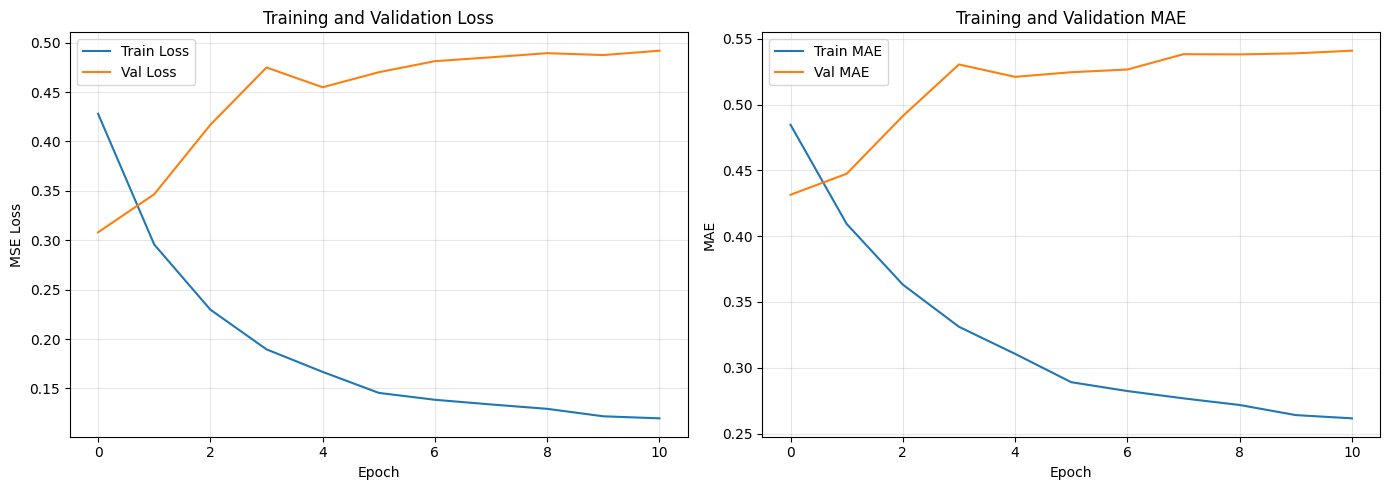

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["loss"], label="Train Loss")
ax1.plot(history.history["val_loss"], label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.set_title("Training and Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["mae"], label="Train MAE")
ax2.plot(history.history["val_mae"], label="Val MAE")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE")
ax2.set_title("Training and Validation MAE")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate

In [25]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f"Test MSE (scaled): {test_loss:.6f}")
print(f"Test MAE (scaled): {test_mae:.6f}")

# Compute metrics in original units
pred_all_scaled = model.predict(x_test)

pred_all = target_scaler.inverse_transform(
    pred_all_scaled.reshape(-1, 1)
).reshape(-1, FORECAST_HORIZON)

true_all = target_scaler.inverse_transform(
    y_test.reshape(-1, 1)
).reshape(-1, FORECAST_HORIZON)

overall_mae = np.mean(np.abs(pred_all - true_all))
overall_rmse = np.sqrt(np.mean((pred_all - true_all) ** 2))

# MAPE (exclude near-zero values)
mask = np.abs(true_all) > 1.0
overall_mape = np.mean(np.abs((true_all[mask] - pred_all[mask]) / true_all[mask])) * 100

print(f"\nTest Results (original units):")
print(f"  Overall MAE:  {overall_mae:.2f} gCO\u2082eq/kWh")
print(f"  Overall RMSE: {overall_rmse:.2f} gCO\u2082eq/kWh")
print(f"  Overall MAPE: {overall_mape:.1f}%")

268/268 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.2543 - mae: 0.3816
Test MSE (scaled): 0.254266
Test MAE (scaled): 0.381566
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step

Test Results (original units):
  Overall MAE:  24.38 gCO₂eq/kWh
  Overall RMSE: 32.22 gCO₂eq/kWh
  Overall MAPE: 42.4%


# Save Model

In [26]:
model.save(os.path.join(MODEL_DIR, "final_model.keras"))

# Convert to TFLite

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

size_kb = os.path.getsize(TFLITE_PATH) / 1024
print(f"TFLite model saved: {TFLITE_PATH} ({size_kb:.1f} KB)")

# Save Hyperparameters

In [27]:
params = {
    "model": "LSTM",
    "window_size": WINDOW_SIZE,
    "forecast_horizon": FORECAST_HORIZON,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "features": FEATURES
}

with open("model_params_lstm.json", "w") as f:
    json.dump(params, f, indent=4)

print("Training complete.")

Training complete.


# One Random 24h Forecast

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


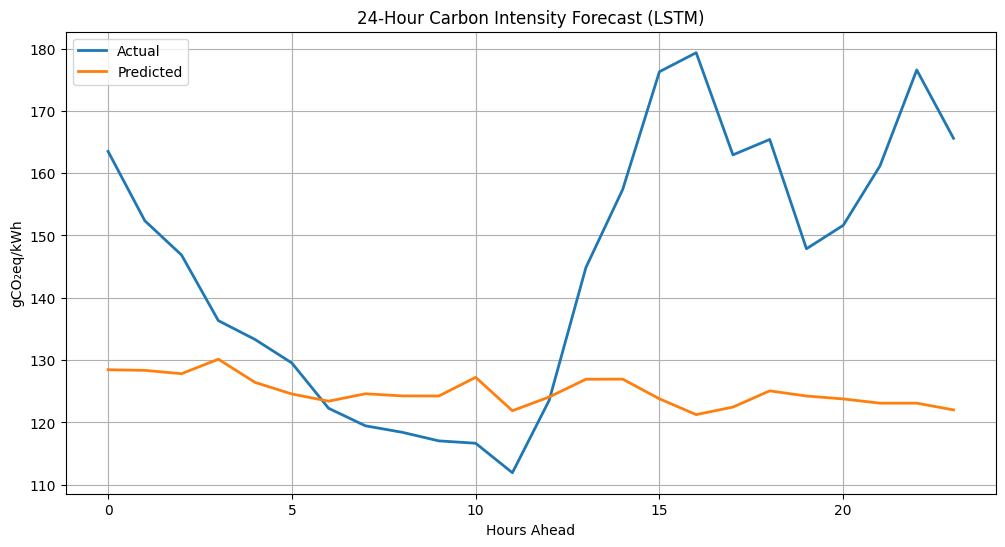

Sample MAE: 23.45 gCO₂eq/kWh


In [28]:
# Pick random test sample
idx = np.random.randint(0, len(x_test))

input_sample = x_test[idx:idx+1]
true_future_scaled = y_test[idx]

# Predict
pred_scaled = model.predict(input_sample)[0]

# Inverse scale
true_future = target_scaler.inverse_transform(
    true_future_scaled.reshape(-1, 1)
).flatten()

pred_future = target_scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).flatten()

# Plot
plt.figure(figsize=(12, 6))
hours = np.arange(FORECAST_HORIZON)

plt.plot(hours, true_future, label="Actual", linewidth=2)
plt.plot(hours, pred_future, label="Predicted", linewidth=2)

plt.title("24-Hour Carbon Intensity Forecast (LSTM)")
plt.xlabel("Hours Ahead")
plt.ylabel("gCO\u2082eq/kWh")
plt.legend()
plt.grid(True)
plt.show()

sample_mae = np.mean(np.abs(true_future - pred_future))
print(f"Sample MAE: {sample_mae:.2f} gCO\u2082eq/kWh")

# Best 3-Hour Charging Window

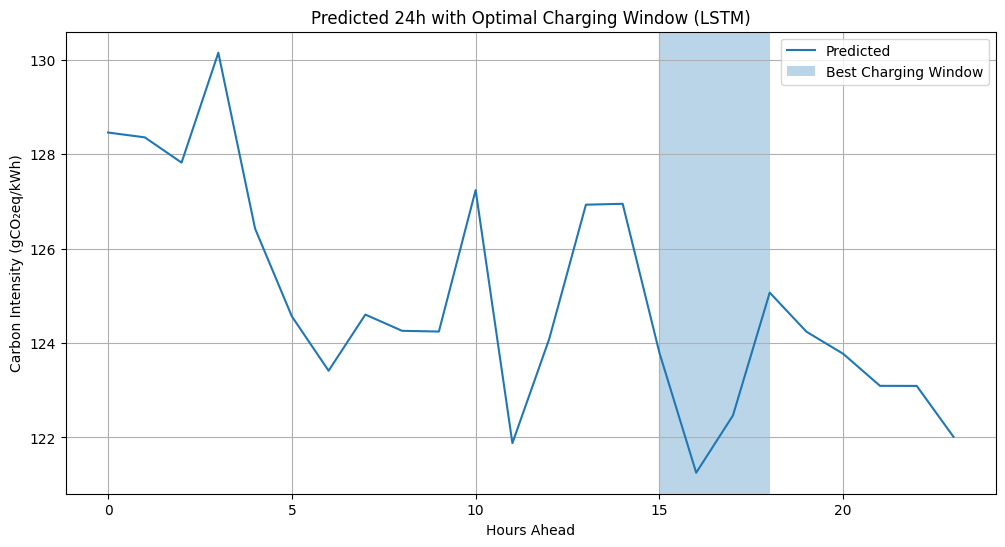

Best charging window: hour 15 to 18


In [29]:
window_size = 3

rolling_avg = np.convolve(
    pred_future,
    np.ones(window_size) / window_size,
    mode='valid'
)

best_start = np.argmin(rolling_avg)
best_end = best_start + window_size

plt.figure(figsize=(12, 6))
plt.plot(hours, pred_future, label="Predicted")

plt.axvspan(best_start, best_end,
            alpha=0.3,
            label="Best Charging Window")

plt.title("Predicted 24h with Optimal Charging Window (LSTM)")
plt.xlabel("Hours Ahead")
plt.ylabel("Carbon Intensity (gCO\u2082eq/kWh)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best charging window: hour {best_start} to {best_end}")

# Evaluate Error Per Forecast Hour

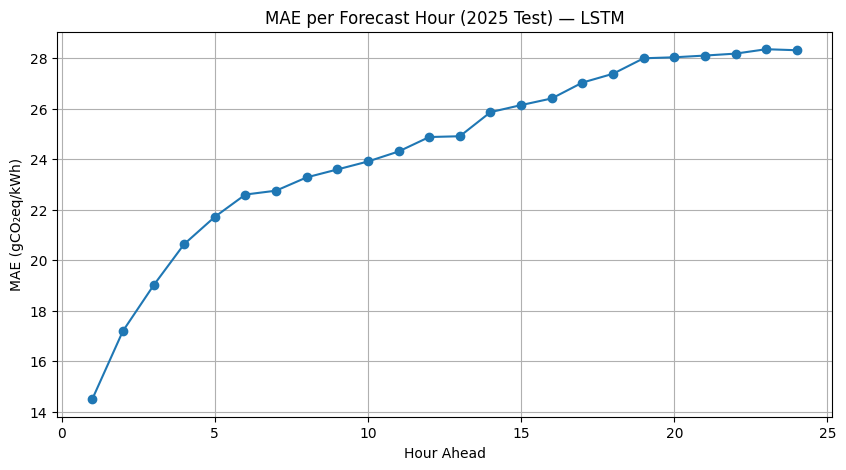

  Hour  1: MAE = 14.49 gCO₂eq/kWh
  Hour  6: MAE = 22.60 gCO₂eq/kWh
  Hour 12: MAE = 24.88 gCO₂eq/kWh
  Hour 18: MAE = 27.39 gCO₂eq/kWh
  Hour 24: MAE = 28.32 gCO₂eq/kWh


In [30]:
mae_per_hour = np.mean(np.abs(pred_all - true_all), axis=0)

plt.figure(figsize=(10, 5))
plt.plot(range(1, FORECAST_HORIZON+1), mae_per_hour, marker='o')
plt.title("MAE per Forecast Hour (2025 Test) — LSTM")
plt.xlabel("Hour Ahead")
plt.ylabel("MAE (gCO\u2082eq/kWh)")
plt.grid(True)
plt.show()

# Print key horizons
for h in [0, 5, 11, 17, 23]:
    print(f"  Hour {h+1:2d}: MAE = {mae_per_hour[h]:.2f} gCO\u2082eq/kWh")

# Full 24h Forecast Distribution

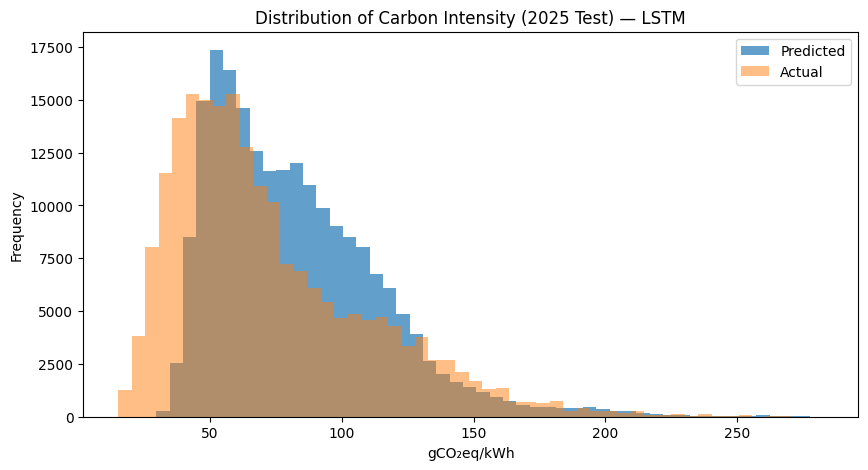

In [31]:
plt.figure(figsize=(10, 5))
plt.hist(pred_all.flatten(), bins=50, alpha=0.7, label="Predicted")
plt.hist(true_all.flatten(), bins=50, alpha=0.5, label="Actual")
plt.title("Distribution of Carbon Intensity (2025 Test) — LSTM")
plt.xlabel("gCO\u2082eq/kWh")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Summer vs Winter Performance

Spring MAE: 22.53 gCO₂eq/kWh
Summer MAE: 17.34 gCO₂eq/kWh
Autumn MAE: 27.41 gCO₂eq/kWh
Winter MAE: 30.99 gCO₂eq/kWh


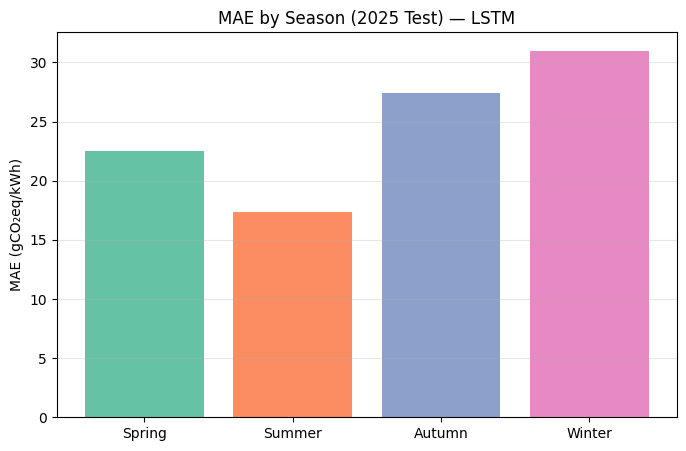

In [32]:
test_dates = test.iloc[WINDOW_SIZE:len(test)-FORECAST_HORIZON]["Datetime (UTC)"]

summer_mask = test_dates.dt.month.isin([6, 7, 8]).values
winter_mask = test_dates.dt.month.isin([12, 1, 2]).values
spring_mask = test_dates.dt.month.isin([3, 4, 5]).values
autumn_mask = test_dates.dt.month.isin([9, 10, 11]).values

summer_mae = np.mean(np.abs(pred_all[summer_mask] - true_all[summer_mask]))
winter_mae = np.mean(np.abs(pred_all[winter_mask] - true_all[winter_mask]))
spring_mae = np.mean(np.abs(pred_all[spring_mask] - true_all[spring_mask]))
autumn_mae = np.mean(np.abs(pred_all[autumn_mask] - true_all[autumn_mask]))

print(f"Spring MAE: {spring_mae:.2f} gCO\u2082eq/kWh")
print(f"Summer MAE: {summer_mae:.2f} gCO\u2082eq/kWh")
print(f"Autumn MAE: {autumn_mae:.2f} gCO\u2082eq/kWh")
print(f"Winter MAE: {winter_mae:.2f} gCO\u2082eq/kWh")

# Bar chart
seasons = ["Spring", "Summer", "Autumn", "Winter"]
maes = [spring_mae, summer_mae, autumn_mae, winter_mae]

plt.figure(figsize=(8, 5))
plt.bar(seasons, maes, color=["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3"])
plt.title("MAE by Season (2025 Test) — LSTM")
plt.ylabel("MAE (gCO\u2082eq/kWh)")
plt.grid(True, alpha=0.3, axis="y")
plt.show()

# Scatter: Predicted vs Actual

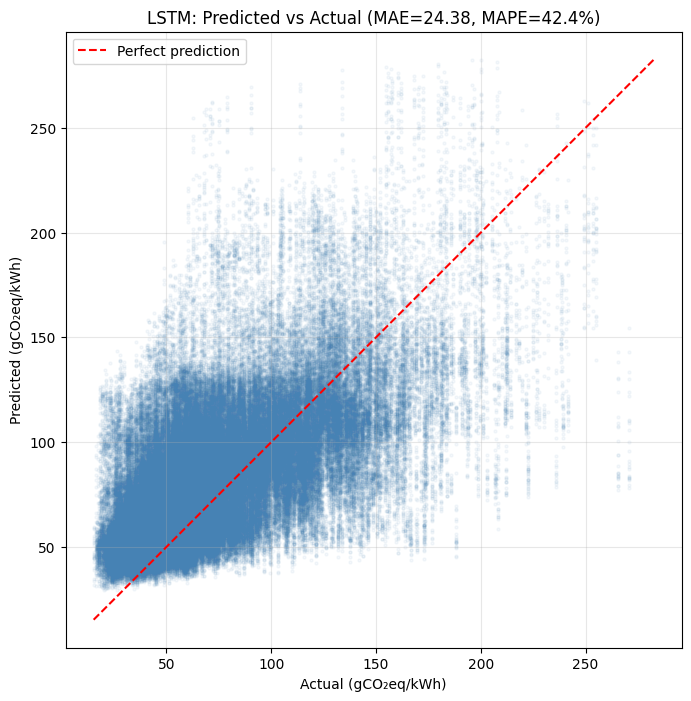

In [33]:
plt.figure(figsize=(8, 8))
pf = pred_all.flatten()
tf_ = true_all.flatten()
plt.scatter(tf_, pf, alpha=0.05, s=5, color="steelblue")
lims = [min(tf_.min(), pf.min()), max(tf_.max(), pf.max())]
plt.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual (gCO\u2082eq/kWh)")
plt.ylabel("Predicted (gCO\u2082eq/kWh)")
plt.title(f"LSTM: Predicted vs Actual (MAE={overall_mae:.2f}, MAPE={overall_mape:.1f}%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().set_aspect("equal")
plt.show()